Transfer Function G(s):
   s + 1   
───────────
s⋅(2⋅s + 1)

Control System:
<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


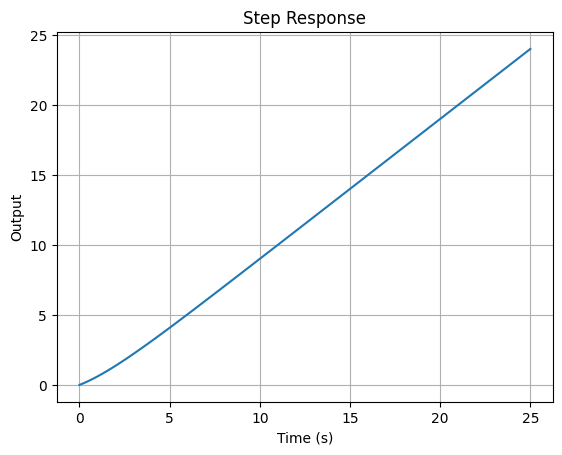

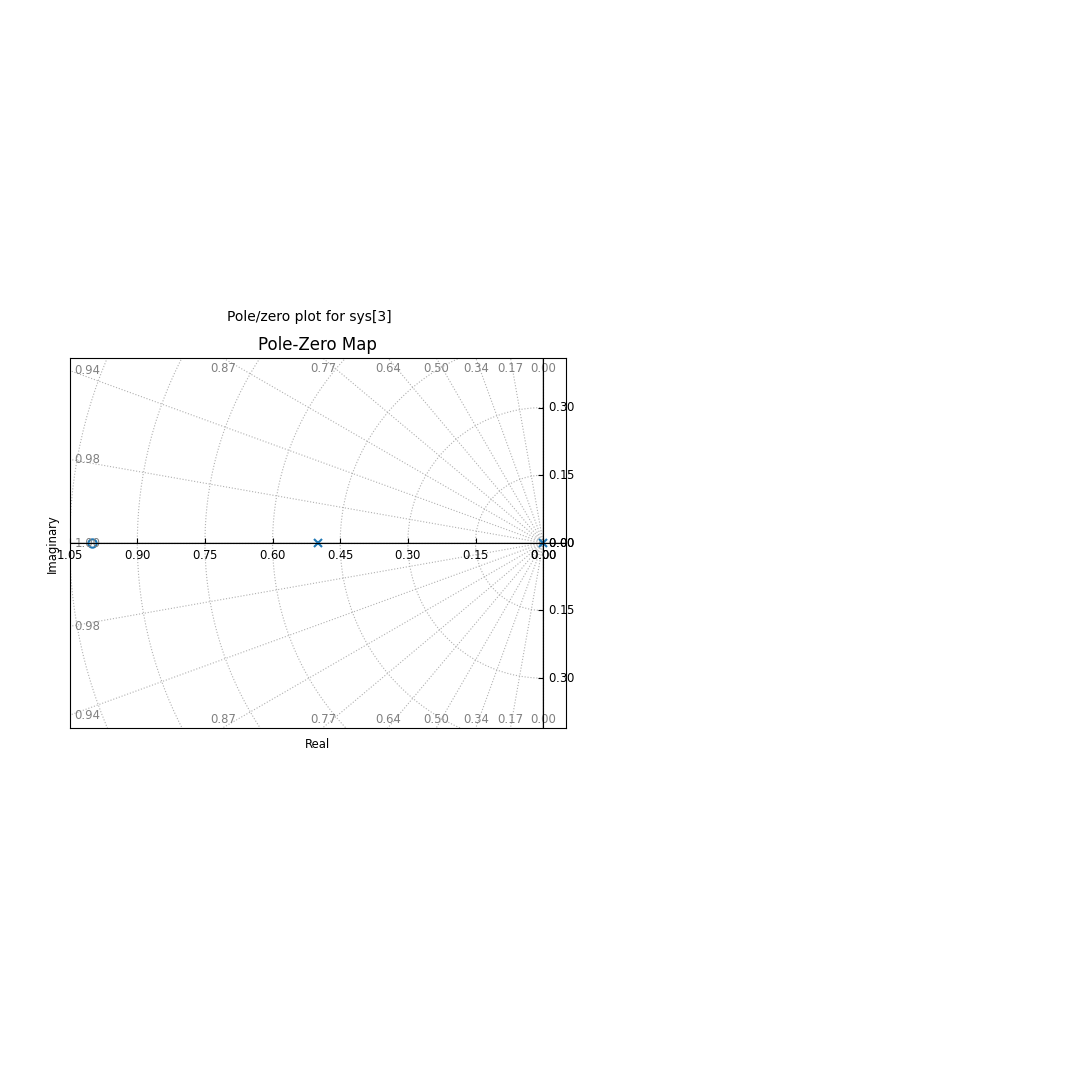

In [2]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from control import tf, step_response, poles, zeros, pzmap

# -----------------------------
# Step 1: Define Laplace variable
# -----------------------------
s = sym.symbols('s')

# -----------------------------
# Step 2: Define Transfer Function
# Given: 2s^2Y + sY = (s+1)X
# -----------------------------
G_s = (s + 1) / (s * (2*s + 1))
G_s = sym.simplify(G_s)

print("Transfer Function G(s):")
sym.pprint(G_s)

# -----------------------------
# Step 3: Convert to numeric TF
# -----------------------------
num = sym.Poly(sym.numer(G_s), s).all_coeffs()
den = sym.Poly(sym.denom(G_s), s).all_coeffs()

num = [float(c) for c in num]
den = [float(c) for c in den]

system = tf(num, den)

print("\nControl System:")
print(system)

# -----------------------------
# Step 4: Poles and Zeros
# -----------------------------
print("\nPoles:", poles(system))
print("Zeros:", zeros(system))

# -----------------------------
# Step 5: Step Response
# -----------------------------
time, response = step_response(system)

plt.figure()
plt.plot(time, response)
plt.title("Step Response")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid()
plt.show()

# -----------------------------
# Step 6: Pole-Zero Map
# -----------------------------
pzmap(system, grid=True)
plt.title("Pole-Zero Map")
plt.show()